# 04 — Bootstrap CI (Poisson TCP, EQD2 / OS proxy)


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
from src.config import DATA_PROCESSED, REPORTS_DIR
from src.models.bootstrap_ci import bootstrap_tcp_params
from src.models.poisson_tcp import PoissonTCPModel
from src.models.model_comparison import run_model_comparison


,parameter,estimate,ci_lower,ci_upper,bootstrap_std,n_bootstrap_success,n_bootstrap_failures
0,D50_gy,53.200458,49.540235,56.749158,1.869507,1000,0
1,gamma50,3.323730,2.057913,4.688614,0.668435,1000,0


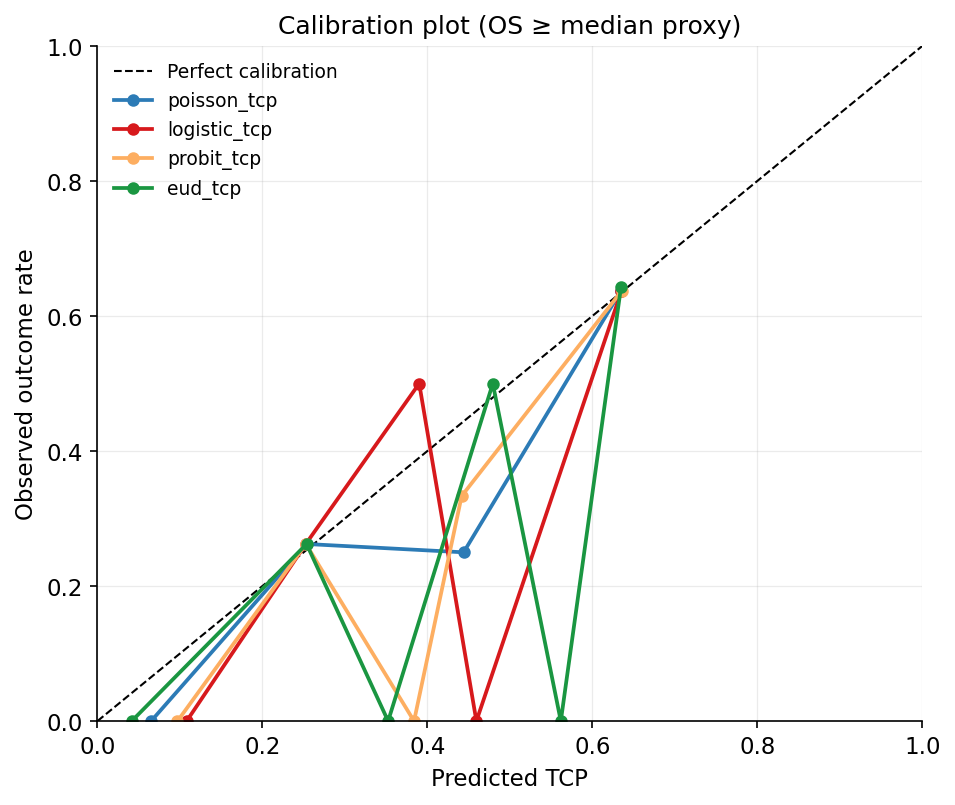

In [2]:
frame = pd.read_csv(DATA_PROCESSED / "modeling_table.csv")
median_os = frame["survival_weeks"].median()
outcomes = (frame["survival_weeks"] >= median_os).astype(float).to_numpy()
doses = frame["eqd2_gy"].to_numpy()

ci = bootstrap_tcp_params(
    PoissonTCPModel, doses, outcomes, n_bootstrap=1000,
    model_factory=lambda: PoissonTCPModel(d50_init=55.0, gamma50_init=1.5),
)
table, _ = run_model_comparison(doses, outcomes, frame=frame)
ci


In [3]:
table.sort_values("aic")[["model", "k_params", "aic", "bic", "roc_auc"]]


,model,k_params,aic,bic,roc_auc
0,probit_tcp,2,241.731266,248.225314,0.683455
1,logistic_tcp,2,241.745486,248.239534,0.683455
2,poisson_tcp,2,241.818325,248.312373,0.683455
3,eud_tcp,3,243.690797,253.431869,0.684951
